In [1]:
# external
import numpy as np
from scipy.stats import norm
from scipy.interpolate import InterpolatedUnivariateSpline as spline
from scipy.optimize import curve_fit
from matplotlib.pyplot import *
cr = rcParams['axes.prop_cycle'].by_key()['color']
# from cmblensplus/utils/
import constant as c
import binning as bn
import plottools as pl
# local
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb

In [27]:
def plot_posterior(Pr,r0,mass,labs,xmax,figname,fsize=[8,5],old=False):
    pl.plot_1dstyle(fsize=fsize,usetex=True,xmin=0,xmax=xmax,ymin=0,ymax=1,
                    xlab=r'$r\times 10^3$',ylab=r'$P(r)/P_{\rm max}$',xlabsize=22,ylabsize=22,
                    xticks_labsize=16,yticks_labsize=16,legend_size=18)
    rcParams["font.family"] = "Arial"
    for i, (lab, m) in enumerate(zip(labs,mass)):
        color, ls = cr[i-1], '-'
        if m=='nodelens': color, ls = 'k', '--'
        plot(rs*1e3,Pr[r0,m]/np.max(Pr[r0,m]),label=lab,color=color,ls=ls)
    if old:
        legend()
    else:
        legend(loc=(-0.1, 1.03),ncol=2)
    savefig(figname, bbox_inches = 'tight', pad_inches = 0.1)

In [3]:
def gauss_fit(x,obsr,sig2):
    return np.exp(-(x-obsr)**2/(sig2*2.))

In [4]:
import importlib
importlib.reload(tools_delens)

<module 'tools_delens' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-postptep-lensing/tools_delens.py'>

In [5]:
simN = 500
lbmin, lbmax = 2, 190
bN = 15
area = 'lbfull'
sigma = 0.6827

In [6]:
pobj = local.analysis()
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename(method='cinv')

In [7]:
mask = tools_cmb.prepare_masks()
Fsky = {m: np.average(mask[m]) for m in tools_cmb.masks}
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')
L = np.linspace(0,lbmax,lbmax+1)
fsky = Fsky[area]
print(fsky)

0.4831339


In [8]:
rmax, dr = 2e-2, 2e-4
rs = np.arange(0.,rmax,dr)

In [9]:
Pr = {}
for obsr in [0.,1e-4,1e-3,2e-3,3e-3,4e-3,5e-3,1e-2]:
    print(obsr)
    for wmass in dobj.ctypes:
        print(wmass)
        Ob, Db, Rb = tools_delens.load_clbbs(dobj.cl[area][wmass],mb,simN,fsky)
        if wmass == 'klb':
            pr = np.array( [ norm.pdf([obsr],loc=r,scale=np.std(tools_delens.simple_r(Ob,Rb,r))) for r in rs ] )
            Pr[obsr,'nodelens'] = pr/(np.sum(pr)*dr)
        pr = np.array( [ norm.pdf([obsr],loc=r,scale=np.std(tools_delens.simple_r(Db,Rb,r))) for r in rs ] )
        Pr[obsr,wmass] = pr/(np.sum(pr)*dr)

0.0
klb
cib
gal
ext
all
0.0001
klb
cib
gal
ext
all
0.001
klb
cib
gal
ext
all
0.002
klb
cib
gal
ext
all
0.003
klb
cib
gal
ext
all
0.004
klb
cib
gal
ext
all
0.005
klb
cib
gal
ext
all
0.01
klb
cib
gal
ext
all


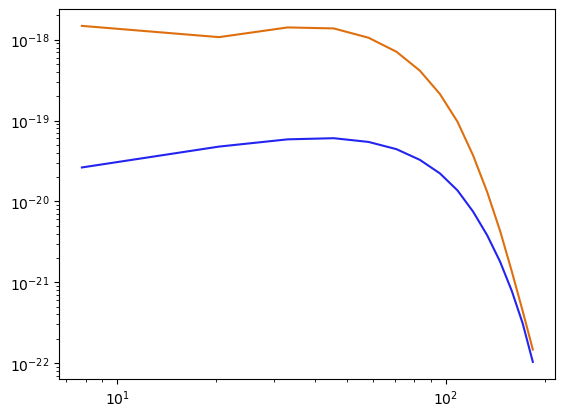

In [10]:
loglog(mb.bc,np.mean(Ob,axis=0))
loglog(mb.bc,np.mean(Rb,axis=0))

In [18]:
mass = np.concatenate((['nodelens'],dobj.ctypes))
labs  = [r'No-delensing',
         r'{\it LiteBIRD} internal',
         r'$+$ CIB',
         r'$+\,\delta_{\rm g}$',
         r'$+$ CIB $+\,\delta_{\rm g}$',
         r'$+$ CIB $+\,\delta_{\rm g}\,+$ CMB small-scale'
        ]

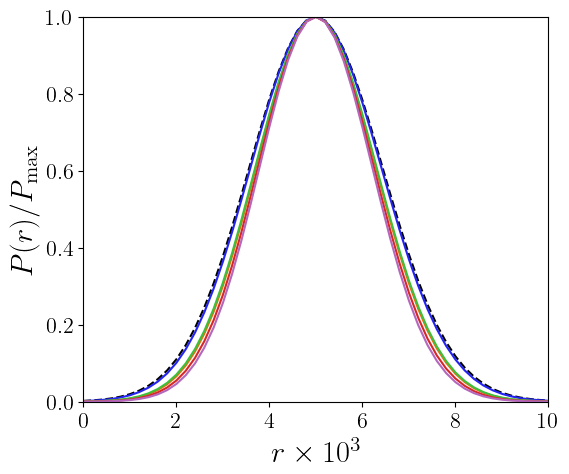

In [19]:
plot_posterior(Pr,5e-3,mass,['','','','','',''],10,'fig_Pr_r5_old.pdf',fsize=[6,5],old=True)

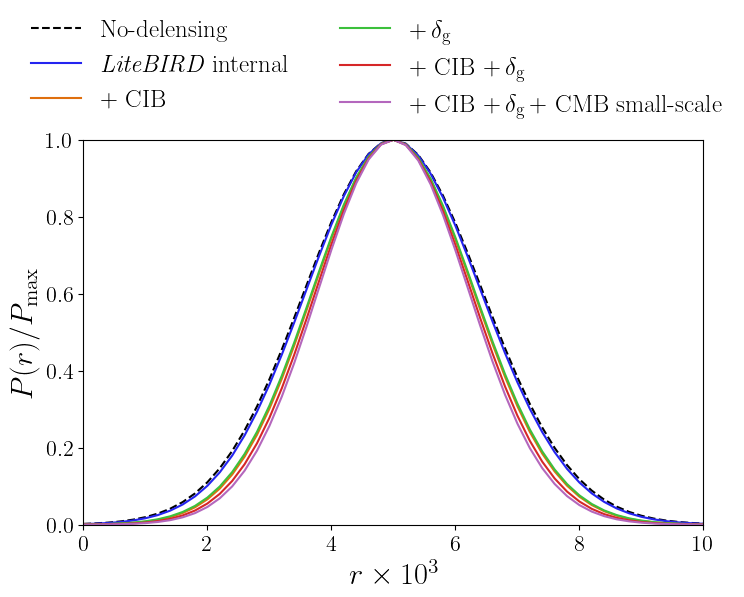

In [28]:
plot_posterior(Pr,5e-3,mass,labs,10,'fig_Pr_r5.pdf')

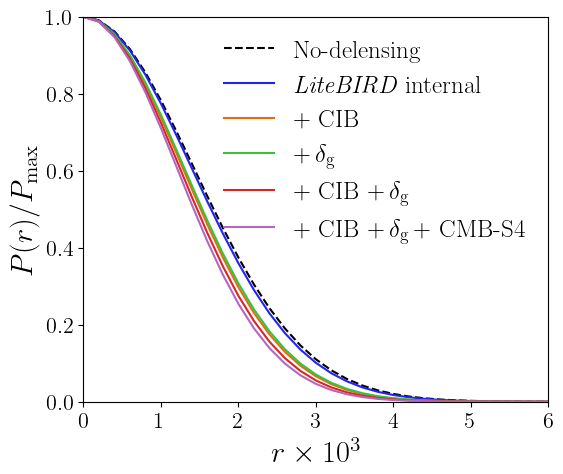

In [14]:
plot_posterior(Pr,0.,mass,labs,6,'fig_Pr_r0.pdf',fsize=[6,5],old=True)

0.0012749999999999999
0.0012749999999999999 1.0
0.001248
0.001248 0.9788235294117648
0.001133
0.001133 0.8886274509803922
0.00115
0.00115 0.9019607843137256
0.001093
0.001093 0.8572549019607844
0.0010559999999999999
0.0010559999999999999 0.8282352941176471


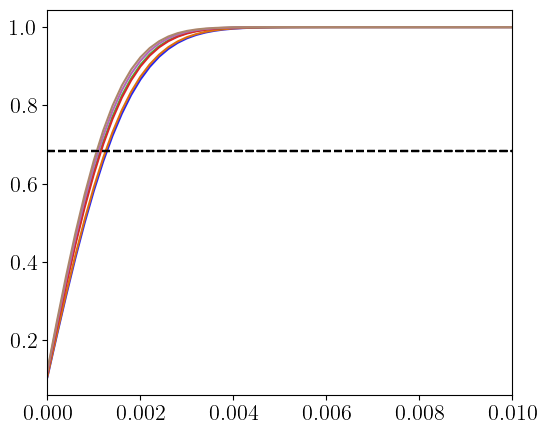

In [15]:
# sigma(r=0) from CDF
r_fine = np.arange(0.,5e-3,1e-6)
for i, wmass in enumerate(mass):
    xlim(0,1e-2)
    cdf = np.cumsum(Pr[0.,wmass]*dr)
    plot(rs,cdf)
    axhline(sigma,color='k',ls='--')
    cdf_sp = spline(rs,cdf)(r_fine)
    idx = np.abs(cdf_sp-sigma).argmin()
    print(r_fine[idx])
    sigr = r_fine[idx]
    if i==0: sig0 = sigr
    print(sigr,sigr/sig0)

0.0014242252951385881 1.0
0.0013974045571527795 0.9811681915232388
0.0012824957550197375 0.9004865728739502
0.0012973665864643782 0.9109279205282859
0.0012409068933317924 0.8712855315570298
0.0012044503888926767 0.84568810356333


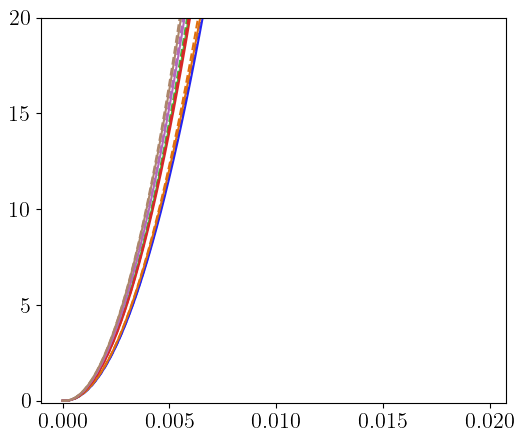

0.001427952760692632 1.0
0.0014006395100545851 0.9808724410289326
0.0012859021390284953 0.9005214839213346
0.0013018854656116055 0.9117146599304327
0.001245169521458596 0.8719962982911448
0.0012087455330710008 0.8464884598035972


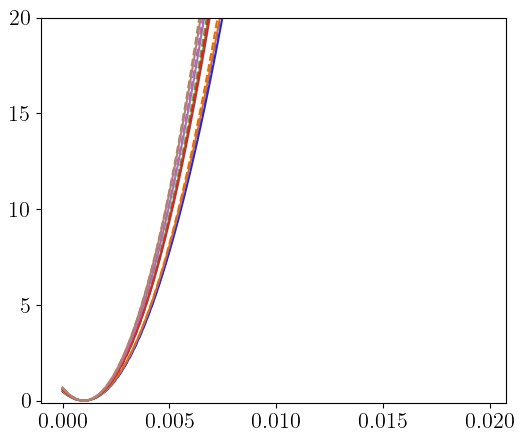

0.0014289042184723983 1.0
0.0014015573195033076 0.9808616290612351
0.001286858555302782 0.900591193354112
0.0013028826615965766 0.9118054553645675
0.001246097839594838 0.8720653375402632
0.0012096753960072237 0.8465755649461613


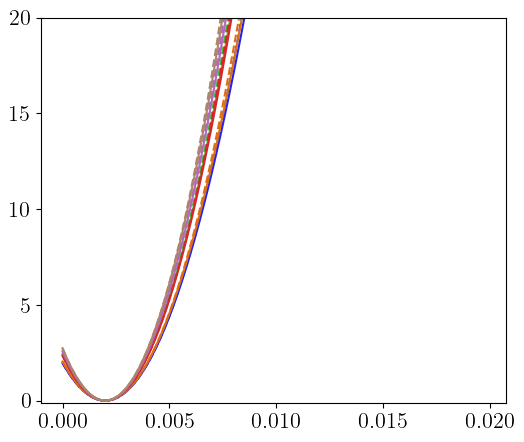

0.0014309960478499759 1.0
0.0014039973893333001 0.9811329608091928
0.0012891575041927604 0.9008812471073396
0.0013044632046888464 0.9115770841217621
0.0012477839681224769 0.8719688429588823
0.0012113882051036132 0.8465349760564914


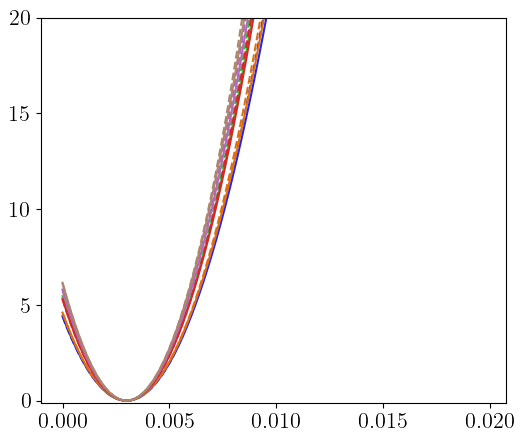

0.0014342729278324356 1.0
0.0014078374229583163 0.9815687067913424
0.0012927272249904375 0.901311877192083
0.0013070315453568848 0.9112850978315222
0.0012505011394613797 0.8718711168530641
0.00121414631381393 0.8465239008929948


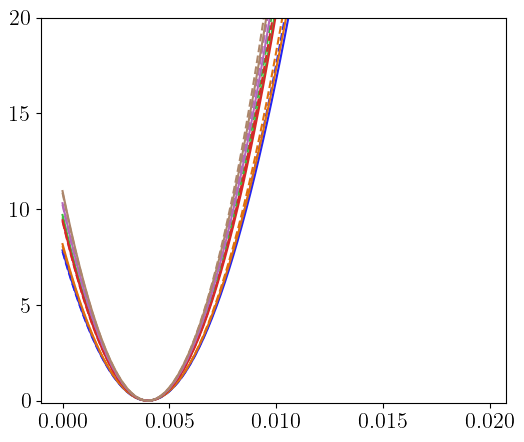

0.0014386942478117196 1.0
0.001412828271855286 0.9820212140308643
0.0012972367584069616 0.9016764753039658
0.0013106328084346078 0.9109877310124124
0.001254151430337715 0.8717289530039495
0.0012178199272980476 0.8464758437384274


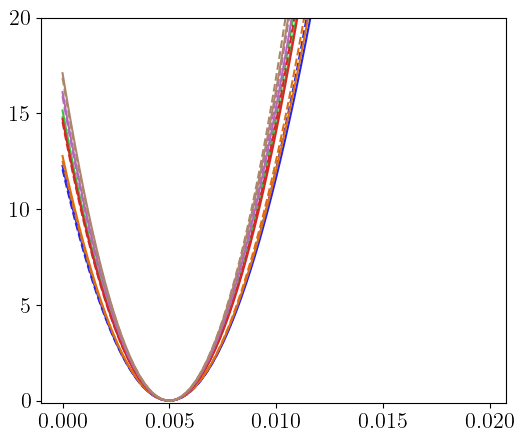

0.0014695191333918495 1.0
0.001445610044117353 0.9837299911711179
0.0013268206054980773 0.9028944063052757
0.0013374422301972821 0.9101223657498654
0.0012803982610462565 0.8713042463699834
0.0012440770300848236 0.8465878407539513


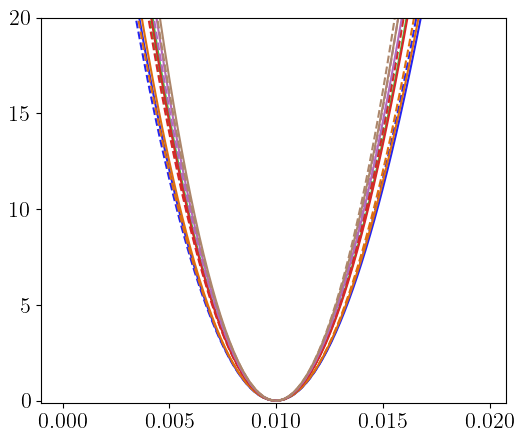

<Figure size 600x500 with 0 Axes>

In [16]:
for r0 in [1e-4,1e-3,2e-3,3e-3,4e-3,5e-3,1e-2]:
    #xlim(0,0.01)
    ylim(-0.1,20)
    for i, m in enumerate(mass):
        x2 = -2*np.log(Pr[r0,m]/np.max(Pr[r0,m]))
        plot(rs,x2,color=cr[i])
        #idx0 = np.abs(x2-0.).argmin()
        #idxp = np.abs(x2[idx0:]-1.).argmin()
        #idxm = np.abs(x2[:idx0]-1.).argmin()
        #print(rs[idx0+idxp],rs[idxm])
        popt, pcov = curve_fit(gauss_fit, rs, Pr[r0,m][:,0]/np.max(Pr[r0,m]), np.array([r0,r0**2]) )
        sigr = np.sqrt(popt[1])
        if i==0: sig0 = sigr
        print(sigr,sigr/sig0)
        pdf = norm.pdf(rs,loc=r0,scale=np.sqrt(popt[1]))
        plot(rs,-2*np.log(pdf/pdf.max()),color=cr[i],ls='--')
    legend()
    show()
    clf()

0.0014695191333918495
0.001445610044117353
0.0013268206054980773
0.0013374422301972821
0.0012803982610462565
0.0012440770300848236


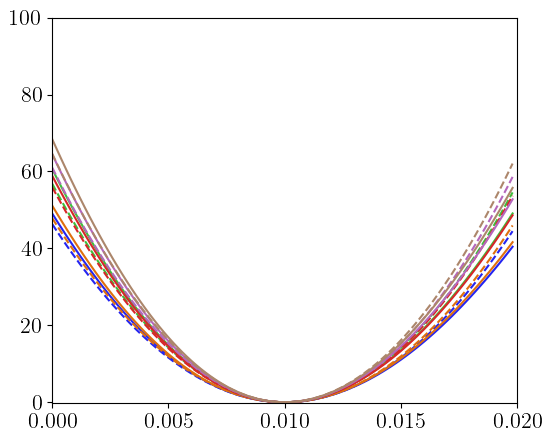

In [17]:
xlim(0,0.02)
ylim(-0.1,100)
r0 = 1e-2
for i, m in enumerate(mass):
    x2 = -2*np.log(Pr[r0,m]/np.max(Pr[r0,m]))
    idx0 = np.abs(x2-0.).argmin()
    idxp = np.abs(x2[idx0:]-1.).argmin()
    idxm = np.abs(x2[:idx0]-1.).argmin()
    #print(rs[idx0+idxp],rs[idxm])
    plot(rs,x2,color=cr[i])
    popt, pcov = curve_fit(gauss_fit, rs, Pr[r0,m][:,0]/np.max(Pr[r0,m]), np.array([r0,r0**2]) )
    #print(popt)
    print(np.sqrt(popt[1]))
    pdf = norm.pdf(rs,loc=r0,scale=popt[1]**0.5)
    plot(rs,-2*np.log(pdf/pdf.max()),color=cr[i],ls='--')
legend()